# Lab 3.1 - K-Means Image Segmentation

This notebook segments an image into visually meaningful color regions using a from-scratch K-Means implementation. The workflow loads an RGB image, resizes it for faster experimentation, converts pixels into feature vectors, clusters those pixels, reconstructs segmented images from centroid colors, and saves figures plus metrics.

## Step 0 - Imports And Setup

The project root, output folders, and deterministic random seed are defined first. Local helper module paths are printed for reproducibility.

In [ ]:
from pathlib import Path
import sys # hello

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RANDOM_SEED = 42
K_VALUES = [2, 3, 5, 8]

from utils import ensure_dir, report_status, save_figure, save_table, setup_seed
from image_io import (
    convert_color_space,
    convert_to_rgb,
    flatten_pixels,
    image_summary,
    load_image_rgb,
    resize_image,
    save_image,
)
from kmeans import KMeansFromScratch, compression_ratio, reconstruct_image
from visualization import color_palette, compare_images, convergence_plot, display_image, k_comparison_grid
from run_pipeline import create_sample_image

setup_seed(RANDOM_SEED)

RAW_DIR = ensure_dir(PROJECT_ROOT / "data" / "raw")
PROCESSED_DIR = ensure_dir(PROJECT_ROOT / "data" / "processed")
METRICS_DIR = ensure_dir(PROCESSED_DIR / "metrics")
FIGURES_DIR = ensure_dir(PROJECT_ROOT / "reports" / "figures")

for module in [sys.modules[name] for name in ["utils", "image_io", "kmeans", "visualization"]]:
    print(f"{module.__name__}: {Path(module.__file__).relative_to(PROJECT_ROOT)}")

utils: src/utils.py
image_io: src/image_io.py
kmeans: src/kmeans.py
visualization: src/visualization.py


## Step 1 - Load The Image

The raw image is kept unchanged in `data/raw/`. If the folder is empty, the notebook creates a deterministic generated landscape image so the exercise can run anywhere without external downloads.

Image path: data/raw/picture.jpg
Shape: (2560, 1920, 3)
dtype: uint8
Pixel range: 0..255
Unique RGB colors: 352969


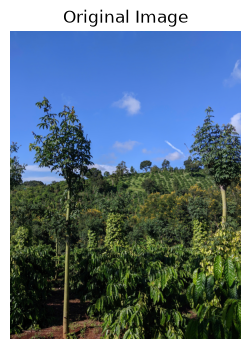

In [2]:
preferred_image = RAW_DIR / "picture.jpg"
image_candidates = sorted(RAW_DIR.glob("*.[jp][pn]g")) + sorted(RAW_DIR.glob("*.jpeg"))
if preferred_image.exists():
    image_path = preferred_image
else:
    image_path = image_candidates[0] if image_candidates else create_sample_image(RAW_DIR / "sample_image.jpg")

original_image = load_image_rgb(image_path)
summary = image_summary(original_image)
print(f"Image path: {image_path.relative_to(PROJECT_ROOT)}")
print(f"Shape: {summary['shape']}")
print(f"dtype: {summary['dtype']}")
print(f"Pixel range: {summary['min']}..{summary['max']}")
print(f"Unique RGB colors: {summary['unique_colors']}")

save_image(original_image, FIGURES_DIR / "original_image.png")
fig = display_image(original_image, "Original Image")
plt.show()

## Step 2 - Preprocess The Image

Resizing keeps clustering fast because K-Means works over one row per pixel. The flattened matrix has shape `(height * width, channels)`, where each row is a pixel color vector. Color space affects distance: RGB clusters raw channel intensity, HSV separates hue from saturation/value, and LAB is designed to be more perceptually uniform.

Resized shape: (350, 262, 3)
Flattened pixel matrix shape: (91700, 3)
Feature dtype: float64


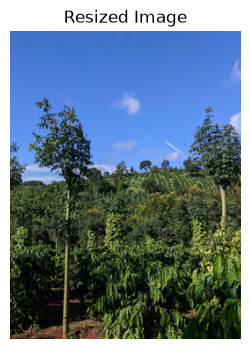

In [3]:
resized_image = resize_image(original_image, max_size=350)
save_image(resized_image, PROCESSED_DIR / "resized_image.png")

pixel_matrix = flatten_pixels(resized_image)
print(f"Resized shape: {resized_image.shape}")
print(f"Flattened pixel matrix shape: {pixel_matrix.shape}")
print(f"Feature dtype: {pixel_matrix.dtype}")

fig = display_image(resized_image, "Resized Image")
plt.show()

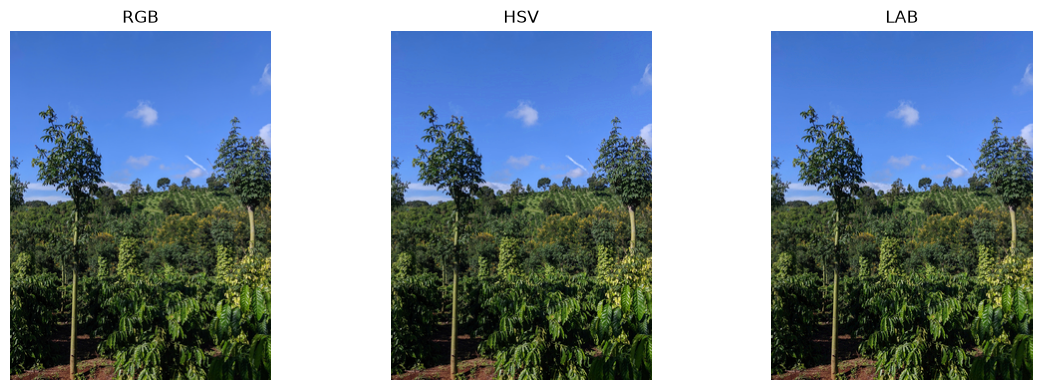

In [4]:
color_space_previews = {"RGB": resized_image}
for color_space in ["HSV", "LAB"]:
    converted = convert_color_space(resized_image, color_space)
    color_space_previews[color_space] = convert_to_rgb(converted, color_space)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (color_space, preview) in zip(axes, color_space_previews.items()):
    ax.imshow(preview)
    ax.set_title(color_space)
    ax.axis("off")
save_figure(fig, FIGURES_DIR / "color_space_preview.png")
plt.show()

## Step 3 - From-Scratch K-Means

The implementation in `notebooks/kmeans.py` manually initializes centroids, computes distances, assigns pixels, updates centroids, tracks inertia and centroid shift, and handles empty clusters. It does not call `sklearn.cluster.KMeans` for the main result.

In [5]:
model_preview = KMeansFromScratch(n_clusters=3, max_iter=10, tol=1e-3, random_state=RANDOM_SEED)
print(model_preview)
print("Fitted attributes after fit: cluster_centers_, labels_, inertia_, n_iter_, inertia_history_, center_shift_history_")

Fitted attributes after fit: cluster_centers_, labels_, inertia_, n_iter_, inertia_history_, center_shift_history_


## Step 4 - Apply K-Means Clustering

The experiment tests `K = 2, 3, 5, 8`. Lower K values create stronger posterization and simpler color regions; higher K values preserve more visual detail while reducing compression.

In [6]:
unique_colors_before = image_summary(resized_image)["unique_colors"]
images_by_k = {}
models_by_k = {}
history_by_k = {}
metrics = []

for k in K_VALUES:
    report_status(f"Fitting K={k}")
    model = KMeansFromScratch(n_clusters=k, max_iter=100, tol=1e-3, random_state=RANDOM_SEED)
    labels = model.fit_predict(pixel_matrix)
    segmented_image = reconstruct_image(labels, model.cluster_centers_, resized_image.shape)
    output_path = PROCESSED_DIR / f"segmented_k{k}.png"
    save_image(segmented_image, output_path)

    unique_colors_after = image_summary(segmented_image)["unique_colors"]
    metrics.append({
        "color_space": "RGB",
        "k": k,
        "inertia": round(model.inertia_, 3),
        "n_iter": model.n_iter_,
        "compression_ratio": round(compression_ratio(unique_colors_before, unique_colors_after), 6),
        "unique_colors_before": unique_colors_before,
        "unique_colors_after": unique_colors_after,
        "output_path": str(output_path.relative_to(PROJECT_ROOT)),
    })
    images_by_k[k] = segmented_image
    models_by_k[k] = model
    history_by_k[k] = model.inertia_history_

metrics_df = pd.DataFrame(metrics)
save_table(metrics_df, METRICS_DIR / "segmentation_metrics.csv")
metrics_df

[lab3_1] Fitting K=2
[lab3_1] Fitting K=3
[lab3_1] Fitting K=5
[lab3_1] Fitting K=8


,color_space,k,inertia,n_iter,compression_ratio,unique_colors_before,unique_colors_after,output_path
0,RGB,2,2.617196e+08,6,0.000042,47119,2,data/processed/segmented_k2.png
1,RGB,3,1.269185e+08,16,0.000064,47119,3,data/processed/segmented_k3.png
2,RGB,5,6.904721e+07,30,0.000106,47119,5,data/processed/segmented_k5.png
3,RGB,8,4.155721e+07,49,0.000170,47119,8,data/processed/segmented_k8.png


## Step 5 - Reconstruct Segmented Images

Each pixel label indexes the fitted centroid table. The centroid colors are reshaped back to the image dimensions, clipped to `[0, 255]`, rounded, and saved as `uint8` images.

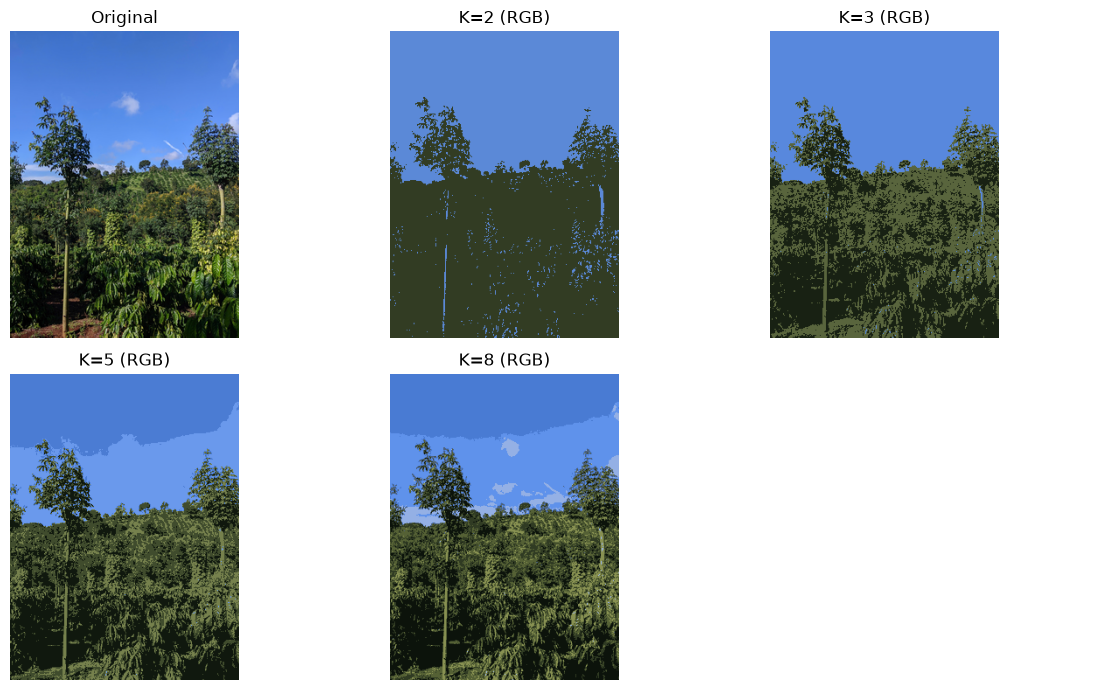

K=2: 2 unique colors
K=3: 3 unique colors
K=5: 5 unique colors
K=8: 8 unique colors


In [7]:
fig = k_comparison_grid(images_by_k, original=resized_image, color_space="RGB")
save_figure(fig, FIGURES_DIR / "k_comparison_grid.png")
plt.show()

for k, image in images_by_k.items():
    print(f"K={k}: {image_summary(image)['unique_colors']} unique colors")

## Step 6 - Visualize Results

The side-by-side figure uses K=5 as a balanced result for this image: it captures the main sky, water, mountain, vegetation, and highlight regions without keeping too much fine texture.

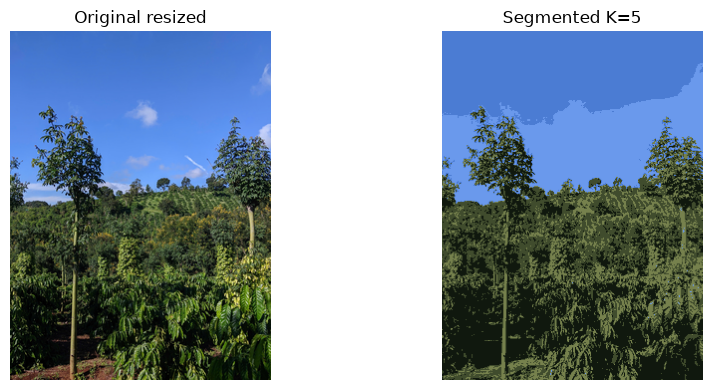

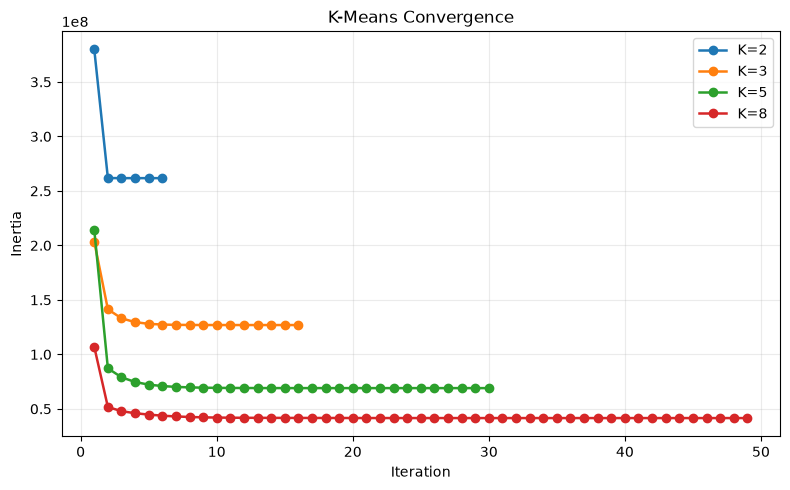

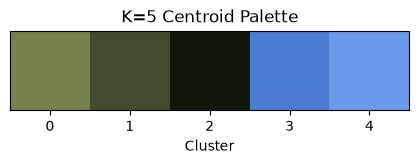

In [8]:
fig = compare_images(resized_image, images_by_k[5], titles=("Original resized", "Segmented K=5"))
save_figure(fig, FIGURES_DIR / "original_vs_segmented.png")
plt.show()

fig = convergence_plot(history_by_k)
save_figure(fig, FIGURES_DIR / "convergence_plot.png")
plt.show()

fig = color_palette(models_by_k[5].cluster_centers_, title="K=5 Centroid Palette")
save_figure(fig, FIGURES_DIR / "color_palette_k5.png")
plt.show()

## Step 7 - Compare Color Spaces

RGB is the primary result for this exercise. The preview above shows how the same image can be represented in HSV and LAB. In a larger experiment, K-Means can be fitted to HSV or LAB feature vectors and then converted back to RGB for display.

In [9]:
space_rows = []
for color_space in ["RGB", "HSV", "LAB"]:
    feature_image = convert_color_space(resized_image, color_space)
    features = flatten_pixels(feature_image)
    model = KMeansFromScratch(n_clusters=5, max_iter=100, tol=1e-3, random_state=RANDOM_SEED).fit(features)
    segmented_features = reconstruct_image(model.labels_, model.cluster_centers_, feature_image.shape)
    segmented_rgb = convert_to_rgb(segmented_features, color_space)
    space_rows.append({"color_space": color_space, "k": 5, "inertia": round(model.inertia_, 3), "n_iter": model.n_iter_})

pd.DataFrame(space_rows)

,color_space,k,inertia,n_iter
0,RGB,5,6.904721e+07,30
1,HSV,5,1.412247e+08,43
2,LAB,5,2.872007e+07,27


## Step 8 - Optional Sklearn Check

Sklearn can be used as a sanity check, but the main exercise result above comes from the manual `KMeansFromScratch` class.

In [10]:
from sklearn.cluster import KMeans

sklearn_model = KMeans(n_clusters=5, random_state=RANDOM_SEED, n_init=10)
sklearn_labels = sklearn_model.fit_predict(pixel_matrix)
print(f"Manual K=5 inertia: {models_by_k[5].inertia_:.3f}")
print(f"Sklearn K=5 inertia: {sklearn_model.inertia_:.3f}")
print(f"Sklearn iterations: {sklearn_model.n_iter_}")

Manual K=5 inertia: 69047213.344
Sklearn K=5 inertia: 69054300.816
Sklearn iterations: 12


## Step 9 - Saved Outputs

The notebook saves segmented images, a metrics CSV, comparison figures, a convergence plot, and a centroid palette. The final selected K is `5` for a compact but readable segmentation.

In [11]:
expected_outputs = [
    PROCESSED_DIR / "resized_image.png",
    *(PROCESSED_DIR / f"segmented_k{k}.png" for k in K_VALUES),
    METRICS_DIR / "segmentation_metrics.csv",
    FIGURES_DIR / "original_image.png",
    FIGURES_DIR / "color_space_preview.png",
    FIGURES_DIR / "k_comparison_grid.png",
    FIGURES_DIR / "convergence_plot.png",
    FIGURES_DIR / "original_vs_segmented.png",
    FIGURES_DIR / "color_palette_k5.png",
]
for path in expected_outputs:
    print(f"{'OK' if path.exists() else 'MISSING'} - {path.relative_to(PROJECT_ROOT)}")

OK - data/processed/resized_image.png
OK - data/processed/segmented_k2.png
OK - data/processed/segmented_k3.png
OK - data/processed/segmented_k5.png
OK - data/processed/segmented_k8.png
OK - data/processed/metrics/segmentation_metrics.csv
OK - reports/figures/original_image.png
OK - reports/figures/color_space_preview.png
OK - reports/figures/k_comparison_grid.png
OK - reports/figures/convergence_plot.png
OK - reports/figures/original_vs_segmented.png
OK - reports/figures/color_palette_k5.png
